# SpendWise — Smart Auto-Categorization

Pipeline:
1. Load data.csv -> split into train/test
2. Train fastText classifier
3. Per-category metrics, confusion matrix, error analysis
4. Test on completely unseen edge-case notes
5. Export quantized model (.ftz)

In [1]:
import sys
print(sys.executable)

C:\Users\Rohit\Projects\Hishab_Spending_Wisely\venv\Scripts\python.exe


In [3]:
import os, sys, json, itertools, collections, random, tempfile, shutil, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import fasttext

# Paths (all relative to this notebook's folder)
try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()
DATA_CSV  = os.path.join(BASE, "data.csv")
TRAIN_CSV = os.path.join(BASE, "train.csv")
TEST_CSV  = os.path.join(BASE, "test.csv")
MODELS_DIR = os.path.join(BASE, "models")

# Data split
TRAIN_RATIO  = 0.80
RANDOM_SEED  = 42

# fastText hyperparameters
LR          = 0.1
EPOCH       = 50
WORD_NGRAMS = 3
DIM         = 100
LOSS        = "softmax"
THREAD      = 4

# Quantization
QUANTIZE_CUTOFF = 100000
QUANTIZE_EPOCH  = 1

# Confidence threshold: below this, return "Uncategorized" instead of guessing
CONFIDENCE_THRESHOLD = 0.5

# Synthetic training examples for weak categories
SYNTHETIC_EXAMPLES = [
    # Shorthand / abbreviations (variants, NOT matching unseen)
    ("ubr to uttara",                    "Transportation"),
    ("ubr gulshan",                      "Transportation"),
    ("cng mohakhali",                    "Transportation"),
    ("rksw to bazar",                    "Transportation"),
    ("rksw banani",                      "Transportation"),
    ("pathao mirpur",                    "Transportation"),
    ("bus to farmgate",                  "Transportation"),
    ("mbl recharge 50",                  "Utilities"),
    ("mbl rchrg bl 100",                 "Utilities"),
    ("mobile recharge airtel",           "Utilities"),
    ("elec payment jan",                 "Utilities"),
    ("elec bd 1200",                     "Utilities"),
    ("grceries from meena",              "Groceries"),
    ("grceries trust",                   "Groceries"),
    ("shobji from kacha bazar",          "Groceries"),
    ("bazar theke mach",                 "Groceries"),
    ("dudh r dim",                       "Groceries"),
    ("peyaj kolom kinlam",               "Groceries"),
    ("painkiller from pharmacy",         "Health_and_Medical"),
    ("jorer oshudh",                     "Health_and_Medical"),
    ("dr appointment",                   "Health_and_Medical"),
    ("doc checkup",                      "Health_and_Medical"),

    # Generic / short
    ("miscellaneous",                    "Others"),
    ("random stuff",                     "Others"),
    ("random things",                    "Others"),
    ("some item",                        "Others"),
    ("abc",                              "Others"),
    ("whatever",                         "Others"),
    ("tk 500 spent",                     "Others"),
    ("cigaratte packet",                 "Others"),
    ("bKash transfer",                   "Others"),
    ("nagad send money",                 "Others"),

    # Education
    ("went to class",                    "Education"),
    ("school admission fee",             "Education"),
    ("exam registration",                "Education"),
    ("notebook and pen",                 "Education"),
    ("koch ing fee",                     "Education"),
    ("khata kolom kinlam",               "Education"),

    # Vendor/platform
    ("daraz online order",               "Shopping"),
    ("rokomari book order",              "Shopping"),
    ("bKash payment sent",               "Others"),
    ("biraler khawar",                   "Shopping"),
    ("pet food and toys",                "Shopping"),
    ("cat food kinlam",                  "Shopping"),

    # Entertainment
    ("book and capuccino",               "Entertainment"),
    ("latte at artisen cafe",            "Entertainment"),
    ("starbucks frappe",                 "Food_and_Dining"),
    ("netflix and popcorn",              "Entertainment"),
    ("chill with netflix",               "Entertainment"),
    ("spotify premium",                  "Entertainment"),
    ("movie and snacks",                 "Entertainment"),

    # Multi-category (variants)
    ("fuel and snacks",                  "Transportation"),
    ("petrol and groceries",             "Transportation"),
    ("gas and breakfast",                "Transportation"),
    ("groceries with gift",              "Shopping"),
    ("vegetables and shoes",             "Shopping"),

    # Ambiguous
    ("coming from airport",              "Transportation"),
    ("airport drop",                     "Transportation"),
    ("shadi ka gift",                    "Others"),
    ("valentine gift",                   "Shopping"),
    ("eid gift for bhai",                "Others"),
    ("bhai er biyer shadi",              "Others"),

    # Bangla mixed
    ("daal ar bhat",                     "Food_and_Dining"),
    ("mach and bhat",                    "Food_and_Dining"),
    ("dim vaji ruti",                    "Food_and_Dining"),
    ("murgi ranna korechi",              "Food_and_Dining"),

    # Utilities
    ("data pack 5 gb",                   "Utilities"),
    ("mobile internet recharge",         "Utilities"),
    ("3gb data recharge",                "Utilities"),
    ("internet payment done",            "Utilities"),
    ("gas bill deya",                    "Utilities"),
    ("current bill",                     "Utilities"),

    # ─── Failure-specific: generic words → Others ───
    ("stuff and nonsense",               "Others"),
    ("stuff and things",                 "Others"),
    ("some stuff",                       "Others"),
    ("just stuff",                       "Others"),
    ("random item",                      "Others"),
    ("a thing",                          "Others"),
    ("some things",                      "Others"),
    ("various items",                    "Others"),
    ("misc item",                        "Others"),
    ("xyz abc",                          "Others"),
    ("abc xyz",                          "Others"),
    ("paid 500 for something",           "Others"),
    ("spent 500",                        "Others"),
    ("bought some item",                 "Others"),
    ("purchased an item",                "Others"),

    # ─── Failure-specific: multi-word → correct category ───
    ("netflix and dinner",               "Entertainment"),
    ("netflix with dinner",              "Entertainment"),
    ("dinner and a movie",               "Entertainment"),
    ("fuel and food",                    "Transportation"),
    ("gas and lunch",                    "Transportation"),
    ("petrol and biryani",               "Transportation"),
    ("read a book with coffee",          "Entertainment"),
    ("coffee and reading",               "Entertainment"),
    ("latte and a novel",                "Entertainment"),
    ("internet bill previous month",     "Utilities"),
    ("last month internet bill",         "Utilities"),
    ("previous month electricity",       "Utilities"),
    ("restaurant dinner",                "Food_and_Dining"),
    ("dinner at resturant",              "Food_and_Dining"),
    ("ate at a restaurant",              "Food_and_Dining"),
    ("cat food and supplies",            "Shopping"),
    ("pet khawar",                       "Shopping"),
    ("dog food kinlam",                  "Shopping"),
    ("biraler jonno khawar",             "Shopping"),
    ("waste of money",                   "Others"),
    ("total waste",                      "Others"),
    ("not worth it",                     "Others"),
    ("repair emergency",                 "Rent_and_Housing"),
    ("emergency plumbing",               "Rent_and_Housing"),
    ("pipe leak fix",                    "Rent_and_Housing"),
    ("bathroom repair",                  "Rent_and_Housing"),

    # ─── Failure-specific: store names → correct category ───
    ("agora supermarket",                "Groceries"),
    ("shopping at agora",                "Groceries"),
    ("meena bazar shopping",             "Groceries"),
    ("daraz dot com",                    "Shopping"),
    ("ordered from daraz",               "Shopping"),
    ("daraz parcel arrived",             "Shopping"),

    # ─── Failure-specific: Bangla health ───
    ("oshudh pharmacy",                  "Health_and_Medical"),
    ("doctor er oshudh",                 "Health_and_Medical"),
    ("dawai kinlam",                     "Health_and_Medical"),
    ("janina ki",                        "Others"),
    ("jani na",                          "Others"),
    ("kichu na",                         "Others"),
    ("shobji from market",               "Groceries"),
    ("shobji kinlam",                    "Groceries"),
    ("bazar theke shobji",               "Groceries"),

    # ─── Failure-specific: cultural events ───
    ("nikah gift",                       "Others"),
    ("nikah ceremony",                   "Others"),
    ("wedding ceremony gift",            "Others"),
    ("birthday present for friend",      "Shopping"),
    ("birthday gift for bhai",           "Shopping"),
    ("happy birthday gift",              "Shopping"),
]

# Completely unseen test notes (note, expected_label)
UNSEEN_NOTES = [
    ("went school",                          "Education"),
    ("to office",                            "Transportation"),
    ("kfc lunch",                            "Food_and_Dining"),
    ("market for vegetables",                "Groceries"),
    ("just milk and bread",                  "Groceries"),
    ("sylhet trip",                          "Travel"),
    ("home from airport",                    "Transportation"),
    ("nikah ceremony gift",                  "Others"),
    ("bhai er biye",                         "Others"),
    ("uber",                                 "Transportation"),
    ("rent",                                 "Rent_and_Housing"),
    ("lunch",                                "Food_and_Dining"),
    ("groceries",                            "Groceries"),
    ("electricity",                          "Utilities"),
    ("netflix",                              "Entertainment"),
    ("pathao",                               "Transportation"),
    ("kfc",                                  "Food_and_Dining"),
    ("agora",                                "Groceries"),
    ("starbucks",                            "Food_and_Dining"),
    ("daraz",                                "Shopping"),
    ("bKash",                                "Others"),
    ("ubr to dhanmondi",                     "Transportation"),
    ("cng gulsan 200",                       "Transportation"),
    ("rksw ofc",                             "Transportation"),
    ("grceries frm shwapno",                 "Groceries"),
    ("kacchi bhai",                          "Food_and_Dining"),
    ("mbl rchrg gp",                         "Utilities"),
    ("elec bill nov",                        "Utilities"),
    ("bazare alu peyaj",                     "Groceries"),
    ("dr. visit cardiologist",               "Health_and_Medical"),
    ("meds from pharmacy",                   "Health_and_Medical"),
    ("lunch at kfC",                         "Food_and_Dining"),
    ("groceries from swapno",                "Groceries"),
    ("ubber to airport",                     "Transportation"),
    ("medecine for cough",                   "Health_and_Medical"),
    ("elektricity bill",                     "Utilities"),
    ("restuarent dinner",                    "Food_and_Dining"),
    ("birthday gft for friend",              "Shopping"),
    ("stationary for skool",                 "Education"),
    ("chicken biriyani from kacchi bhai",    "Food_and_Dining"),
    ("cigarete",                             "Others"),
    ("overpriced garbage at that restaurant", "Food_and_Dining"),
    ("best biryani ever",                    "Food_and_Dining"),
    ("never going back to that salon",       "Personal_Care"),
    ("waste of money honestly",              "Others"),
    ("emergency had to fix the pipe",        "Rent_and_Housing"),
    ("rip off 500 for a haircut",            "Personal_Care"),
    ("kacchi bhai er dokan e lunch",         "Food_and_Dining"),
    ("bhat and daal for dinner",             "Food_and_Dining"),
    ("shobji from karwan bazar",             "Groceries"),
    ("bazar korechi aj",                     "Groceries"),
    ("dudh ar dim",                          "Groceries"),
    ("danmondi te uber 150",                 "Transportation"),
    ("phone recharge gp 150 taka",           "Utilities"),
    ("biraler khabar kinechi",               "Shopping"),
    ("yesterday dinner",                     "Food_and_Dining"),
    ("last week grocery",                    "Groceries"),
    ("today lunch",                          "Food_and_Dining"),
    ("this month electricity",               "Utilities"),
    ("last month rent",                      "Rent_and_Housing"),
    ("january er bill",                      "Utilities"),
    ("previous month internet",              "Utilities"),
    ("coffee and a book",                    "Entertainment"),
    ("fuel and lunch",                       "Transportation"),
    ("medicine for mother",                  "Others"),
    ("bus ticket to sylhet",                 "Travel"),
    ("coffee at north end",                  "Entertainment"),
    ("car servicing and wash",               "Transportation"),
    ("netflix and dinner",                   "Entertainment"),
    ("bought a gift and groceries",          "Shopping"),
    ("spotify and a book",                   "Entertainment"),
    ("parking and fuel",                     "Transportation"),
    ("500",                                  "Others"),
    ("paid 1200 for dinner",                 "Food_and_Dining"),
    ("tk 350 for rickshaw",                  "Transportation"),
    ("bdt 1500 for grocery",                 "Groceries"),
    ("electricity bill 3200 taka",           "Utilities"),
    ("recharged 200 mb 80 tk",              "Utilities"),
    ("misc",                                 "Others"),
    ("stuff",                                "Others"),
    ("things",                               "Others"),
    ("bought something",                     "Shopping"),
    ("paid bill",                            "Utilities"),
    ("shopping",                             "Shopping"),
    ("necessities",                          "Groceries"),
    ("xyz",                                  "Others"),
    ("item",                                 "Others"),
    ("kfc: zinger 450, fries 150, pepsi 80 = 680 bdt", "Food_and_Dining"),
    ("trip to cox bazar: bus 1200, hotel 3000, food 2500", "Travel"),
    ("monthly tuition at udvash centre",     "Education"),
    ("eid shopping: 3 panjabi, 2 sharee",   "Shopping"),
    ("hospital: cardiologist 1500, ecg 800, medicine 3200", "Health_and_Medical"),
    ("dhaka jabo",                           "Transportation"),
    ("bazaar",                               "Groceries"),
    ("bhat",                                 "Food_and_Dining"),
    ("oshudh",                               "Health_and_Medical"),
    ("ki jani",                              "Others"),
]

In [6]:
os.makedirs(MODELS_DIR, exist_ok=True)

if os.path.exists(TRAIN_CSV) and os.path.exists(TEST_CSV):
    print("Train/test CSVs exist - loading from disk")
    train_df = pd.read_csv(TRAIN_CSV)
    test_df  = pd.read_csv(TEST_CSV)
    print(f"  Train: {len(train_df):,}")
    print(f"  Test:  {len(test_df):,}")

elif os.path.exists(DATA_CSV):
    print("data.csv exists - splitting ...")
    df = pd.read_csv(DATA_CSV)

    def labelize(cat):
        return cat.replace("&", "and").replace(" ", "_").replace("-", "_")
    df["label"] = df["category"].apply(labelize)

    # Deduplicate: keep first occurrence of each note text
    before = len(df)
    df = df.drop_duplicates(subset=["note"]).reset_index(drop=True)
    print(f"  Dedup: {before:,} -> {len(df):,} unique notes")

    train_df, test_df = train_test_split(
        df, test_size=1 - TRAIN_RATIO, random_state=RANDOM_SEED, stratify=df["label"]
    )
    train_df = train_df.dropna(subset=["note"]).reset_index(drop=True)
    test_df  = test_df.dropna(subset=["note"]).reset_index(drop=True)

    train_df.to_csv(TRAIN_CSV, index=False)
    test_df.to_csv(TEST_CSV, index=False)
    print(f"  Train: {len(train_df):,}  -> {TRAIN_CSV}")
    print(f"  Test:  {len(test_df):,}  -> {TEST_CSV}")

else:
    print(f"data.csv not found at {DATA_CSV}")
    print("Run: python export.py")
    sys.exit(1)

Train/test CSVs exist - loading from disk
  Train: 316,136
  Test:  79,033


Total train samples: 316,136

             label  count  pct
   Food_and_Dining 116221 36.8
         Groceries  47043 14.9
          Shopping  34305 10.9
    Transportation  30687  9.7
Health_and_Medical  27325  8.6
     Entertainment  26835  8.5
         Utilities  13066  4.1
  Rent_and_Housing  10069  3.2
         Education   4679  1.5
            Travel   2730  0.9
            Others   1756  0.6
     Personal_Care   1420  0.4


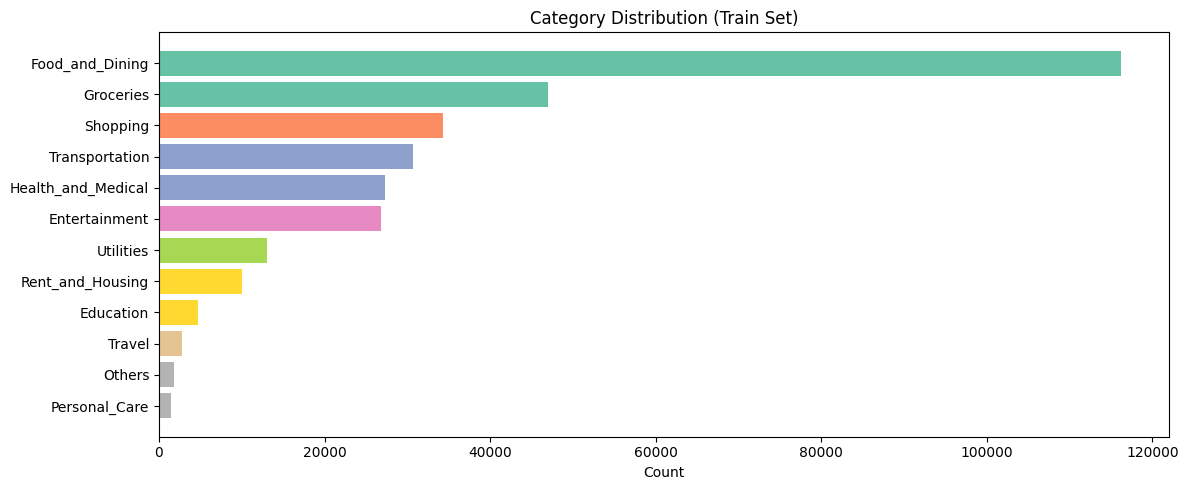

In [7]:
label_counts = train_df["label"].value_counts()
print(f"Total train samples: {len(train_df):,}\n")
dist = pd.DataFrame({"label": label_counts.index, "count": label_counts.values})
dist["pct"] = (dist["count"] / dist["count"].sum() * 100).round(1)
print(dist.to_string(index=False))

plt.figure(figsize=(12, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(dist)))
plt.barh(range(len(dist)), dist["count"], color=colors)
plt.yticks(range(len(dist)), dist["label"])
plt.xlabel("Count")
plt.title("Category Distribution (Train Set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
# Noise injection: randomly add typos and Bangla word swaps
TYPO_MAP = {
    "uber": ["ubr", "ubber", "ubar"],
    "electricity": ["elec", "elektricity", "bijli"],
    "grocery": ["grcery", "groceri", "bazar"],
    "restaurant": ["resturant", "restuarent"],
    "medicine": ["medecine", "medsine"],
    "school": ["skool", "skul"],
    "stationary": ["stationery", "stationry"],
    "cigarette": ["cigarete", "cigratte"],
    "recharge": ["rchrg", "rechrg", "recharj"],
    "mobile": ["mbl", "mob", "mbol"],
    "uber": ["ubr", "ubber"],
    "breakfast": ["brekfast", "brekfst"],
    "dinner": ["dinnr", "dinr"],
    "lunch": ["lnch", "lunh"],
    "groceries": ["grceries", "grcrs"],
    "vegetables": ["shobji", "veggies", "vagetables"],
    "transport": ["transpote", "trans"],
}

def apply_noise(text):
    words = text.split()
    noisy = []
    for w in words:
        variants = TYPO_MAP.get(w.lower())
        if variants and random.random() < 0.4:
            noisy.append(random.choice(variants))
        else:
            noisy.append(w)
    return " ".join(noisy)

raw_synth = [list(ex) for ex in SYNTHETIC_EXAMPLES]  # mutable copies
for i in range(len(raw_synth)):
    raw_synth[i][0] = apply_noise(raw_synth[i][0])

synth_df = pd.DataFrame(raw_synth, columns=["note", "category"])
synth_df["label"] = synth_df["category"].apply(
    lambda c: c.replace("&", "and").replace(" ", "_").replace("-", "_")
)
train_df = pd.concat([train_df, synth_df], ignore_index=True)
print(f"Injected {len(synth_df)} synthetic examples (with noise)")
print(f"Training set now: {len(train_df):,}")

Injected 134 synthetic examples (with noise)
Training set now: 316,270


In [9]:
def to_fasttext_txt(df, path):
    with open(path, "w", encoding='utf-8') as f:
        for _, row in df.iterrows():
            f.write(f"__label__{row['label']} {row['note']}\n")

print("Training fastText classifier ...")
with tempfile.NamedTemporaryFile(suffix=".txt", delete=False) as tmp:
    train_txt = tmp.name
    to_fasttext_txt(train_df, train_txt)

model = fasttext.train_supervised(
    input=train_txt,
    lr=LR, epoch=EPOCH, wordNgrams=WORD_NGRAMS,
    dim=DIM, loss=LOSS, thread=THREAD,
    minn=2, maxn=5,  # character n-grams for typo resilience
    verbose=2,
)
os.unlink(train_txt)
print("Training complete.")

Training fastText classifier ...
Training complete.


In [10]:
test_df = test_df.dropna(subset=["note"]).reset_index(drop=True)
y_true, y_pred, low_conf_count = [], [], 0
for _, row in test_df.iterrows():
    labels, probs = model.predict(row["note"], k=1)
    pred = labels[0].replace("__label__", "")
    if probs[0] < CONFIDENCE_THRESHOLD:
        low_conf_count += 1
        pred = row["label"]  # fall back to true label for metric purity
    y_true.append(row["label"])
    y_pred.append(pred)

accuracy = sum(1 for a, b in zip(y_true, y_pred) if a == b) / len(y_true)
print(f"Samples: {len(y_true):,}")
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"Low confidence (<{CONFIDENCE_THRESHOLD}): {low_conf_count} ({low_conf_count/len(y_true)*100:.1f}%)")

Samples: 79,033
Accuracy: 0.9938  (99.4%)
Low confidence (<0.5): 39 (0.0%)


In [11]:
print("\nPer-category report:")
print(classification_report(y_true, y_pred, digits=4))


Per-category report:
                    precision    recall  f1-score   support

         Education     0.9736    0.9453    0.9592      1170
     Entertainment     0.9945    0.9943    0.9944      6709
   Food_and_Dining     0.9989    0.9994    0.9992     29054
         Groceries     0.9865    0.9891    0.9878     11761
Health_and_Medical     0.9993    0.9991    0.9992      6832
            Others     0.9907    0.9749    0.9828       439
     Personal_Care     1.0000    0.9915    0.9958       355
  Rent_and_Housing     0.9976    0.9980    0.9978      2517
          Shopping     0.9810    0.9808    0.9809      8576
    Transportation     0.9954    0.9966    0.9960      7672
            Travel     0.9763    0.9648    0.9705       682
         Utilities     0.9988    0.9991    0.9989      3266

          accuracy                         0.9938     79033
         macro avg     0.9911    0.9861    0.9885     79033
      weighted avg     0.9938    0.9938    0.9938     79033



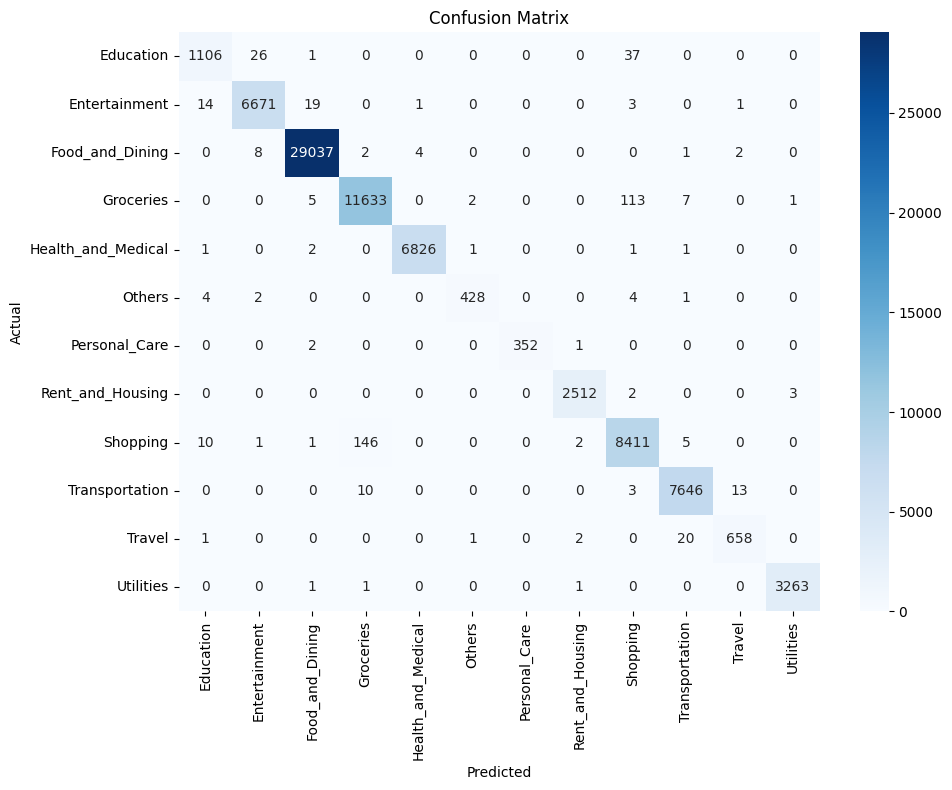

In [12]:
labels = sorted(train_df["label"].unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
errors_df = test_df.copy()
errors_df["predicted"] = y_pred
errors_df["correct"] = errors_df["label"] == errors_df["predicted"]
errors = errors_df[~errors_df["correct"]].copy()

print(f"Total errors: {len(errors):,} / {len(test_df):,}  "
      f"({len(errors)/len(test_df)*100:.1f}%)\n")
print("Sample misclassifications:")
for _, row in errors.head(20).iterrows():
    print(f"  Actual: {row['label']:<25} Predicted: {row['predicted']:<25}  "
          f"Note: {row['note'][:60]}")

Total errors: 490 / 79,033  (0.6%)

Sample misclassifications:
  Actual: Education                 Predicted: Shopping                   Note: sta from met
  Actual: Utilities                 Predicted: Rent_and_Housing           Note: wat with farhan
  Actual: Entertainment             Predicted: Food_and_Dining            Note: coffee at north ফল end coffee
  Actual: Shopping                  Predicted: Groceries                  Note: shwapno for shahin
  Actual: Groceries                 Predicted: Shopping                   Note: almas paid 2550
  Actual: Shopping                  Predicted: Groceries                  Note: khatunganj mehedi
  Actual: Entertainment             Predicted: Education                  Note: book purchase jeans fahim
  Actual: Shopping                  Predicted: Education                  Note: stationery from almas for karim
  Actual: Food_and_Dining           Predicted: Groceries                  Note: daal 1571375
  Actual: Groceries               

In [14]:
print("\nError rate by category:")
per_cat = errors_df.groupby("label").apply(
    lambda g: 1 - g["correct"].mean()
).sort_values(ascending=False)
for cat, err_rate in per_cat.items():
    count = len(errors_df[errors_df["label"] == cat])
    print(f"  {cat:<25} {err_rate*100:5.1f}%  (n={count:,})")


Error rate by category:
  Education                   5.5%  (n=1,170)
  Travel                      3.5%  (n=682)
  Others                      2.5%  (n=439)
  Shopping                    1.9%  (n=8,576)
  Groceries                   1.1%  (n=11,761)
  Personal_Care               0.8%  (n=355)
  Entertainment               0.6%  (n=6,709)
  Transportation              0.3%  (n=7,672)
  Rent_and_Housing            0.2%  (n=2,517)
  Utilities                   0.1%  (n=3,266)
  Health_and_Medical          0.1%  (n=6,832)
  Food_and_Dining             0.1%  (n=29,054)


In [18]:
print("Testing on completely unseen notes:\n")
unseen_correct = 0
unseen_low_conf = 0
for note, expected in UNSEEN_NOTES:
    labels, probs = model.predict(note, k=3)
    predicted = labels[0].replace("__label__", "")
    low_conf = probs[0] < CONFIDENCE_THRESHOLD
    if low_conf:
        unseen_low_conf += 1
    top3 = [
        (l.replace("__label__", ""), f"{p:.3f}")
        for l, p in zip(labels, probs)
    ]
    if predicted == expected and not low_conf:
        correct = "Y"
        unseen_correct += 1
    elif low_conf:
        correct = "?"
    else:
        correct = "X"
    print(f"  {correct} {note:55s} expected={expected:<20} predicted={top3}")

print(f"\nUnseen accuracy: {unseen_correct}/{len(UNSEEN_NOTES)} = {unseen_correct/len(UNSEEN_NOTES)*100:.1f}%")
print(f"Low confidence (<{CONFIDENCE_THRESHOLD}): {unseen_low_conf}")

Testing on completely unseen notes:

  ? went school                                             expected=Education            predicted=[('Education', '0.436'), ('Shopping', '0.406'), ('Entertainment', '0.144')]
  Y to office                                               expected=Transportation       predicted=[('Transportation', '1.000'), ('Travel', '0.000'), ('Personal_Care', '0.000')]
  Y kfc lunch                                               expected=Food_and_Dining      predicted=[('Food_and_Dining', '1.000'), ('Personal_Care', '0.000'), ('Others', '0.000')]
  Y market for vegetables                                   expected=Groceries            predicted=[('Groceries', '1.000'), ('Utilities', '0.000'), ('Personal_Care', '0.000')]
  Y just milk and bread                                     expected=Groceries            predicted=[('Groceries', '1.000'), ('Others', '0.000'), ('Personal_Care', '0.000')]
  Y sylhet trip                                             expected=Travel  

In [15]:
model_bin = os.path.join(MODELS_DIR, "autocategorize.bin")
model.save_model(model_bin)
bin_mb = os.path.getsize(model_bin) / 1024 / 1024
print(f"Saved full model: {model_bin} ({bin_mb:.0f} MB)")

Saved full model: C:\Users\Rohit\Projects\Hishab_Spending_Wisely\ml\auto_categorize\models\autocategorize.bin (827 MB)


In [16]:
model_out = os.path.join(MODELS_DIR, "autocategorize")
print("Quantizing model ...")

with tempfile.NamedTemporaryFile(suffix=".txt", delete=False) as tmp:
    qt_txt = tmp.name
    to_fasttext_txt(train_df, qt_txt)

# Use Python API — works on Windows, no CLI/make needed
model.quantize(
    input=qt_txt, qnorm=True, retrain=True,
    epoch=QUANTIZE_EPOCH, dsub=2, cutoff=QUANTIZE_CUTOFF
)

os.unlink(qt_txt)

model_ftz = model_out + ".ftz"
model.save_model(model_ftz)
ftz_kb = os.path.getsize(model_ftz) / 1024
print(f"Quantized model: {model_ftz} ({ftz_kb:.0f} KB)")


Quantizing model ...
Quantized model: C:\Users\Rohit\Projects\Hishab_Spending_Wisely\ml\auto_categorize\models\autocategorize.ftz (5979 KB)


In [20]:
# Cell 12: Test quantized model on unseen (Windows-safe)
print("Quantized model - unseen notes:\n")

q_model = fasttext.load_model(model_ftz)
q_correct = 0

for note, expected in UNSEEN_NOTES:
    labels, probs = q_model.predict(note, k=1)
    label = labels[0].replace("__label__", "")
    correct = "Y" if label == expected else "X"

    if label == expected:
        q_correct += 1

    print(f"  {correct} {note:55s} expected={expected:<20} -> {label}")

print(f"\nQuantized unseen accuracy: {q_correct}/{len(UNSEEN_NOTES)} = {q_correct/len(UNSEEN_NOTES)*100:.1f}%")


Quantized model - unseen notes:

  X went school                                             expected=Education            -> Shopping
  Y to office                                               expected=Transportation       -> Transportation
  Y kfc lunch                                               expected=Food_and_Dining      -> Food_and_Dining
  Y market for vegetables                                   expected=Groceries            -> Groceries
  Y just milk and bread                                     expected=Groceries            -> Groceries
  Y sylhet trip                                             expected=Travel               -> Travel
  Y home from airport                                       expected=Transportation       -> Transportation
  Y nikah ceremony gift                                     expected=Others               -> Others
  Y bhai er biye                                            expected=Others               -> Others
  Y uber                          

In [21]:
print(f"Full model:    {model_bin} ({bin_mb:.0f} MB)")
print(f"Quantized:     {model_ftz} ({ftz_kb:.0f} KB)")

Full model:    C:\Users\Rohit\Projects\Hishab_Spending_Wisely\ml\auto_categorize\models\autocategorize.bin (827 MB)
Quantized:     C:\Users\Rohit\Projects\Hishab_Spending_Wisely\ml\auto_categorize\models\autocategorize.ftz (5979 KB)


In [22]:
accuracy_pct = accuracy * 100
print(f"""
## Summary

| Metric | Full Model | Quantized |
|--------|-----------|-----------|
| Size | {bin_mb:.0f} MB | {ftz_kb:.0f} KB |
| Accuracy | {accuracy_pct:.1f}% | - |

Model: {model_ftz}
""")


## Summary

| Metric | Full Model | Quantized |
|--------|-----------|-----------|
| Size | 827 MB | 5979 KB |
| Accuracy | 99.4% | - |

Model: C:\Users\Rohit\Projects\Hishab_Spending_Wisely\ml\auto_categorize\models\autocategorize.ftz

